In [14]:
import time
p = 0.4 # Probability of winning

S = {i for i in range(0, 101)} # State space [0, 100]

def A(s):
    return {i for i in range(0, min(s, 100 - s) + 1)} # Can only bet[0, min(s, 100 - s)]

def P(s_next, a, s): # Winning has probability p, Losing has probability 1 - p, else probability 0
    if s_next == s + a:
        return p
    elif s_next == s - a:
        return 1 - p
    else:
        return 0
   
def R(s, a): # Reward is 1 if reach state 100, else 0
    if s == 100:
        return 1
    else:
        return 0

In [15]:
def Value_Iteration(S, A, P, R, theta=1e-30, discount_factor=1):
    V = {s: 0 for s in S} # Initialize value function to 0 for all states
    iteration = 0
    while True:
        iteration += 1
        oldV = V.copy()
       
        for s in S:
            Q = {}

            for a in A(s): # For each action available in state s calculate Q(s, a)
                Q[a] = R(s, a) + discount_factor * sum(P(s_next, a, s) * oldV[s_next] for s_next in S)

            V[s] = max(Q.values()) if Q else 0 # Update V(s) to the maximum Q(s, a)

        delta = max(abs(V[s] - oldV[s]) for s in S) # Checking convergence Criteria
        if delta < theta:
            break

    return V, iteration


In [16]:
start_time = time.perf_counter()
optimV, iterations = Value_Iteration(S, A, P, R)
optimPolicy = {}

for s in S:
    Q = {}
   
    for a in A(s): # For each action available in state s calculate Q(s, a)
        Q[a] = R(s, a) + sum(P(s_next, a, s) * optimV[s_next] for s_next in S)

    optimPolicy[s] = max(Q, key=lambda x: round(Q.get(x), 10)) if Q else 0

end_time = time.perf_counter()
print(f"Time: {end_time - start_time:.2f} seconds")

Time: 5.49 seconds


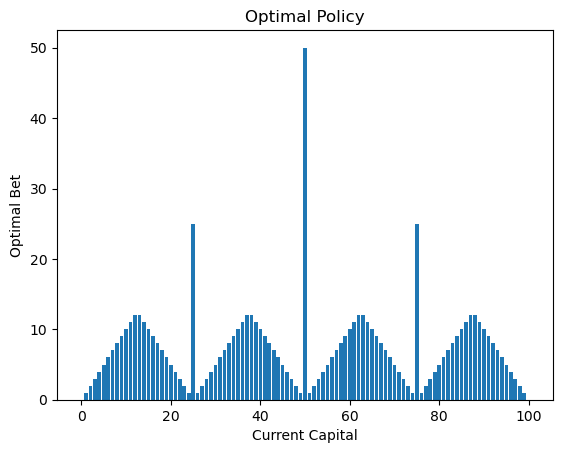

Iterations: 63


In [17]:
import matplotlib.pyplot as plt

plt.bar(optimPolicy.keys(), optimPolicy.values())
plt.xlabel('Current Capital')
plt.ylabel('Optimal Bet')
plt.title('Optimal Policy')
plt.show()
print(f"Iterations: {iterations}")